In [1]:
import os
import numpy as np
import glob
import matplotlib.pyplot as plt

# Auto

### Full sky

#### Fiducial

In [1]:
# Load the file
data = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_nobaryons512_cross_cls_bins1234_noisy_s0.26.npz")

# Access specific cross power spectra
cross_12 = data['cls_1_2']  # (1,2) cross spectrum
cross_13 = data['cls_1_3']  # (1,3) cross spectrum
cross_14 = data['cls_1_4']  # (1,4) cross spectrum
cross_23 = data['cls_2_3']  # (2,3) cross spectrum
cross_24 = data['cls_2_4']  # (2,4) cross spectrum
cross_34 = data['cls_3_4']  # (3,4) cross spectrum

# Check available keys
print(data.files)

NameError: name 'np' is not defined

In [2]:
print("Available cross power spectra:")
for key in data.files:
    if key.startswith('cls_'):
        print(f"  {key}: {data[key].shape}")

Available cross power spectra:


NameError: name 'data' is not defined

In [4]:
# load metadata
bin_range = data['bin_range']  
lmax = data['lmax']
if 'missing_bins' in data.files:
    missing_bins = data['missing_bins']

(1e-11, 1e-07)

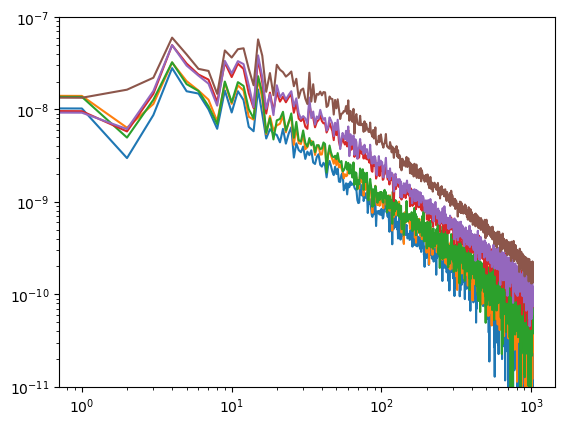

In [ ]:
plt.loglog(cross_12)
plt.loglog(cross_13)
plt.loglog(cross_14)
plt.loglog(cross_23)
plt.loglog(cross_24)
plt.loglog(cross_34)

plt.ylim(1e-11, 1e-7)

#### aggregated

In [2]:
aggregated_data = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cross_cls_fiducial_nobaryons_bins1234_noisy_s0.26..npy")

In [3]:
aggregated_data.shape

(200, 6150)

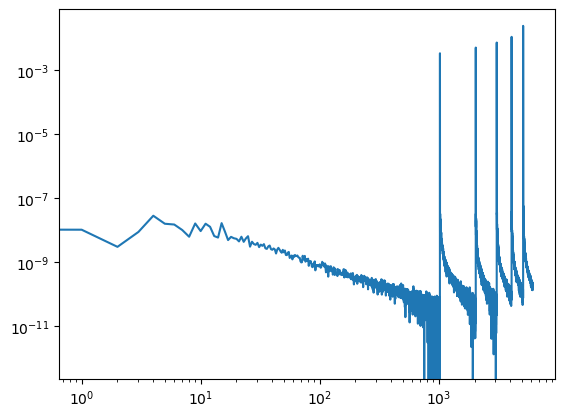

In [8]:
plt.loglog(aggregated_data[0])

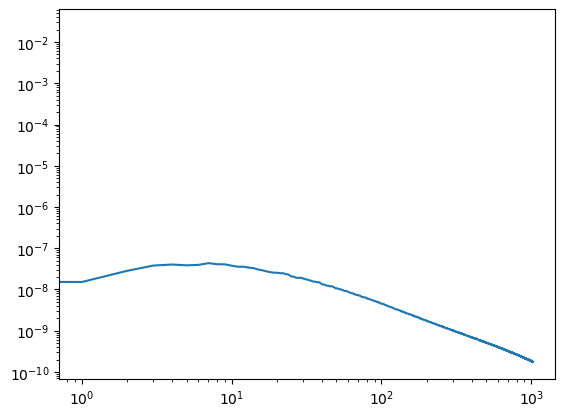

In [9]:
plt.loglog(aggregated_data.mean(axis=0)[5*1025:])

(1e-10, 1e-07)

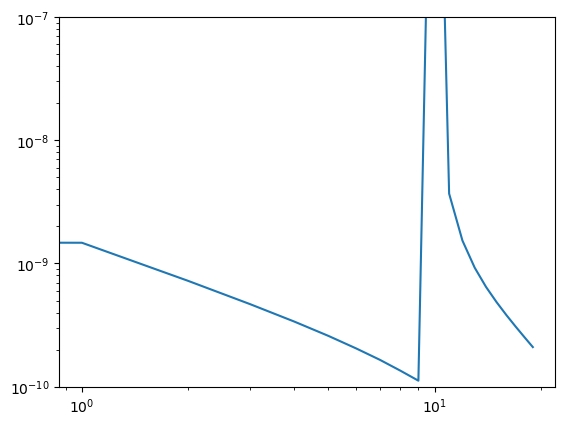

In [3]:
# rebin the mean spectrum by a factor of 10
mean_spectrum = aggregated_data.mean(axis=0)
rebin_factor = 100
rebinned_spectrum = mean_spectrum[:len(mean_spectrum) - len(mean_spectrum) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
plt.loglog(rebinned_spectrum[4*1025//rebin_factor:])
plt.ylim(1e-10, 1e-7)

#### baryonified

In [4]:
aggregated_data_bar = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cross_cls_fiducial_baryonified_bins1234_noisy_s0.26.npy")

In [5]:
aggregated_data_bar.shape

(200, 6150)

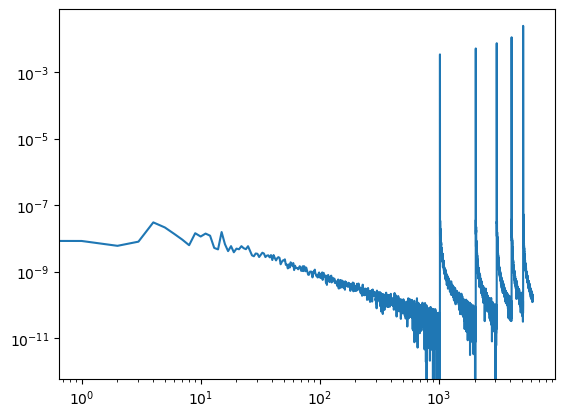

In [6]:
plt.loglog(aggregated_data_bar[0])

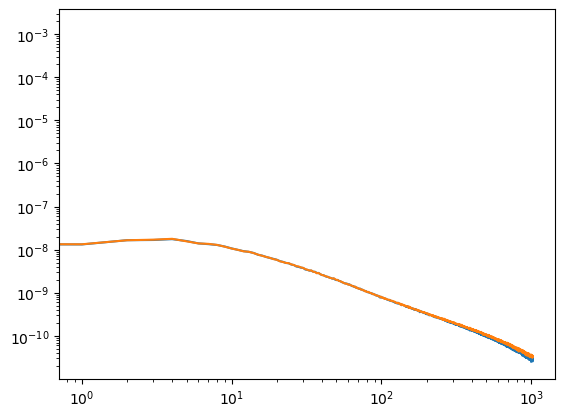

In [7]:
plt.loglog(aggregated_data_bar.mean(axis=0)[:1025])
plt.loglog(aggregated_data.mean(axis=0)[:1025])

(1e-11, 1e-09)

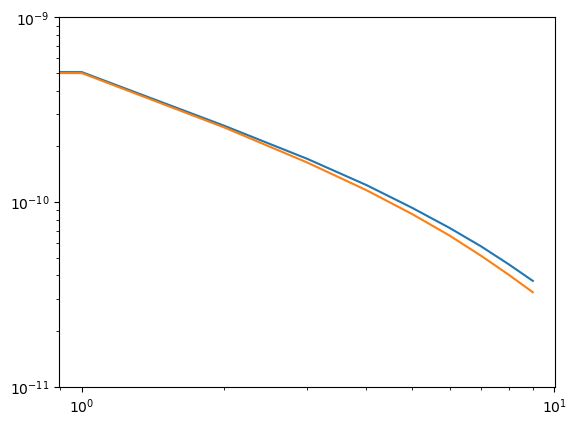

In [8]:
# rebin the mean spectrum by a factor of 10
mean_spectrum_bar = aggregated_data_bar.mean(axis=0)
rebin_factor = 100
rebinned_spectrum_bar = mean_spectrum_bar[:len(mean_spectrum_bar) - len(mean_spectrum_bar) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
plt.loglog(rebinned_spectrum[:1025//rebin_factor])
plt.loglog(rebinned_spectrum_bar[:1025//rebin_factor])
plt.ylim(1e-11, 1e-9)

### Grid

In [23]:
data_grid = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_cross_cls_grid_nobaryons_bins1234_noisy_s0.26.npy")

In [29]:
# rebin the data
rebin_factor = 100
rebinned_data_grid = data_grid[:, :data_grid.shape[1] - data_grid.shape[1] % rebin_factor].reshape(data_grid.shape[0], -1, rebin_factor).mean(axis=2)
rebinned_data_grid.shape

(16965, 61)

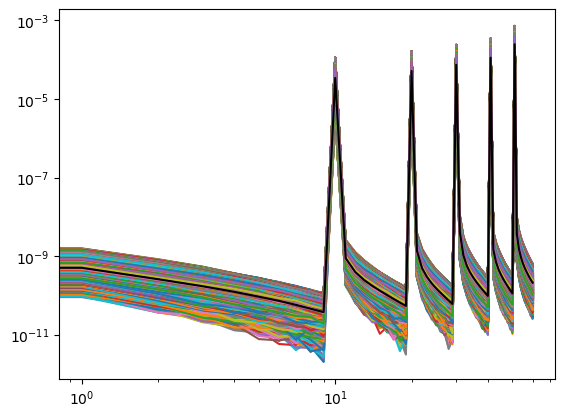

In [37]:
for i in range(16965):
    plt.loglog(rebinned_data_grid[i])
plt.loglog(rebinned_spectrum, color='black')
# plt.ylim(1e-12, 1e-8)

## Masked

### Fiducial

In [ ]:
# Load the file
data = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_nobaryons512_cross_cls_bins1234_noisy_s0.26.npz")

# Access specific cross power spectra
cross_12 = data['cls_1_2']  # (1,2) cross spectrum
cross_13 = data['cls_1_3']  # (1,3) cross spectrum
cross_14 = data['cls_1_4']  # (1,4) cross spectrum
cross_23 = data['cls_2_3']  # (2,3) cross spectrum
cross_24 = data['cls_2_4']  # (2,4) cross spectrum
cross_34 = data['cls_3_4']  # (3,4) cross spectrum

# Check available keys
print(data.files)

['cls_1_2', 'cls_1_3', 'cls_1_4', 'cls_2_3', 'cls_2_4', 'cls_3_4', 'bin_range', 'lmax']


In [ ]:
print("Available cross power spectra:")
for key in data.files:
    if key.startswith('cls_'):
        print(f"  {key}: {data[key].shape}")

Available cross power spectra:
  cls_1_2: (1025,)
  cls_1_3: (1025,)
  cls_1_4: (1025,)
  cls_2_3: (1025,)
  cls_2_4: (1025,)
  cls_3_4: (1025,)


In [ ]:
# load metadata
bin_range = data['bin_range']  
lmax = data['lmax']
if 'missing_bins' in data.files:
    missing_bins = data['missing_bins']

(1e-11, 1e-07)

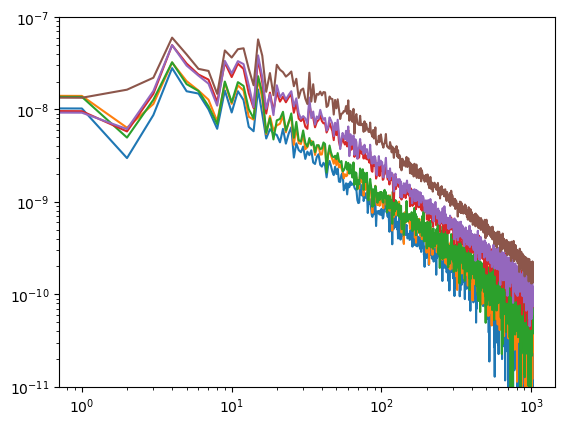

In [ ]:
plt.loglog(cross_12)
plt.loglog(cross_13)
plt.loglog(cross_14)
plt.loglog(cross_23)
plt.loglog(cross_24)
plt.loglog(cross_34)

plt.ylim(1e-11, 1e-7)

#### aggregated

In [22]:
aggregated_data = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin4_masked_14300sqdeg_noisy_s0.26.npy")

In [23]:
aggregated_data.shape

(200, 1025)

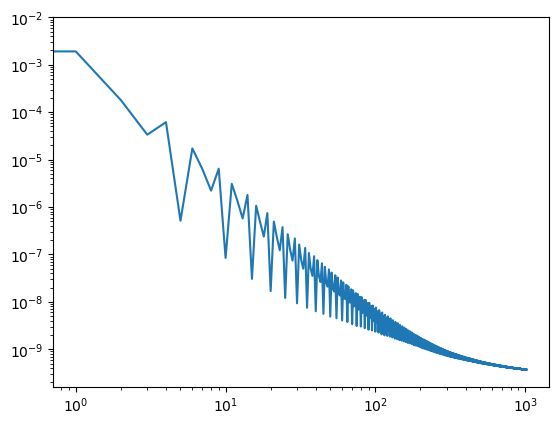

In [25]:
plt.loglog(aggregated_data.mean(axis=0))

(1e-10, 1e-06)

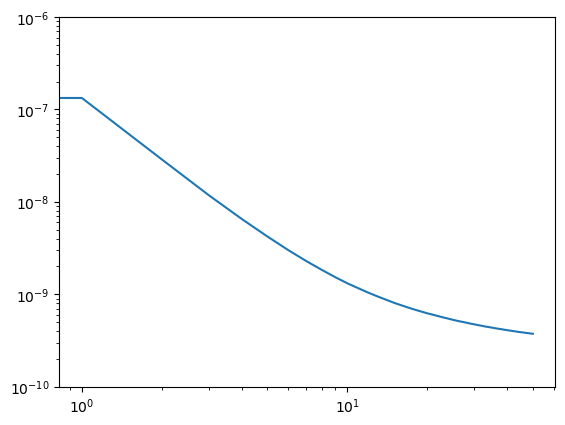

In [27]:
# rebin the mean spectrum by a factor of 10
mean_spectrum = aggregated_data.mean(axis=0)
rebin_factor = 20
rebinned_spectrum = mean_spectrum[:len(mean_spectrum) - len(mean_spectrum) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
plt.loglog(rebinned_spectrum)
plt.ylim(1e-10, 1e-6)

#### baryonified

In [28]:
aggregated_data_bar = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin4_masked_14300sqdeg_noisy_s0.26.npy")

In [29]:
aggregated_data_bar.shape

(200, 1025)

(1e-10, 1e-06)

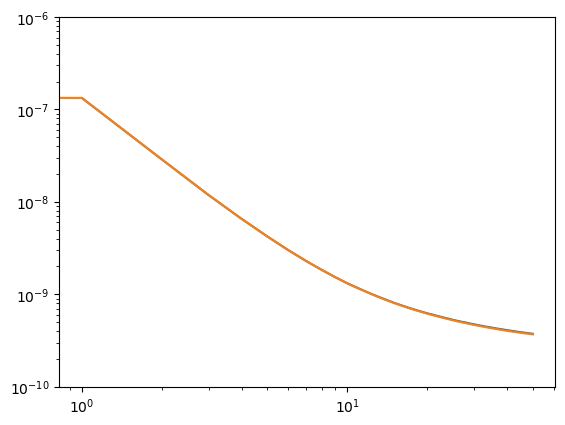

In [33]:
# rebin the mean spectrum by a factor of 10
mean_spectrum_bar = aggregated_data_bar.mean(axis=0)
rebin_factor = 20
rebinned_spectrum_bar = mean_spectrum_bar[:len(mean_spectrum_bar) - len(mean_spectrum_bar) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
plt.loglog(rebinned_spectrum)
plt.loglog(rebinned_spectrum_bar)
plt.ylim(1e-10, 1e-6)

### Grid

In [34]:
data_grid = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_cls_grid_nobaryons_bin4_masked_14300sqdeg_noisy_s0.26.npy")

In [35]:
# rebin the data
rebin_factor = 20
rebinned_data_grid = data_grid[:, :data_grid.shape[1] - data_grid.shape[1] % rebin_factor].reshape(data_grid.shape[0], -1, rebin_factor).mean(axis=2)
rebinned_data_grid.shape

(16965, 51)

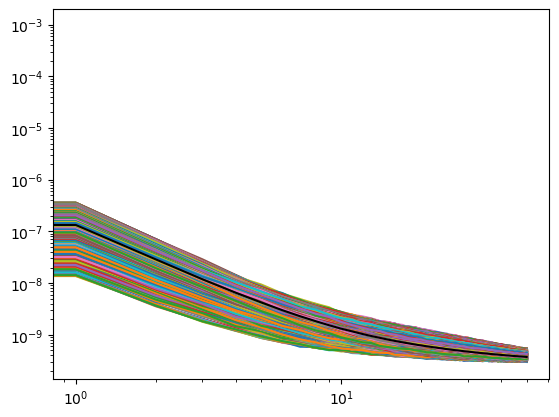

In [36]:
for i in range(16965):
    plt.loglog(rebinned_data_grid[i])
plt.loglog(rebinned_spectrum, color='black')
# plt.ylim(1e-12, 1e-8)

# BNT

## Fiducial

In [38]:
# Load the file
data_bnt = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_nobaryons512_bnt_cross_cls_bins1234_noisy_s0.26.npz")

# Access specific cross power spectra
cross_12_bnt = data_bnt['cls_1_2']  # (1,2) cross spectrum
cross_13_bnt = data_bnt['cls_1_3']  # (1,3) cross spectrum
cross_14_bnt = data_bnt['cls_1_4']  # (1,4) cross spectrum
cross_23_bnt = data_bnt['cls_2_3']  # (2,3) cross spectrum
cross_24_bnt = data_bnt['cls_2_4']  # (2,4) cross spectrum
cross_34_bnt = data_bnt['cls_3_4']  # (3,4) cross spectrum

# Check available keys
print(data_bnt.files)

['cls_1_2', 'cls_1_3', 'cls_1_4', 'cls_2_3', 'cls_2_4', 'cls_3_4', 'bnt_bin_range', 'bin_range', 'lmax']


In [39]:
print("Available cross power spectra:")
for key in data_bnt.files:
    if key.startswith('cls_'):
        print(f"  {key}: {data_bnt[key].shape}")

Available cross power spectra:
  cls_1_2: (1025,)
  cls_1_3: (1025,)
  cls_1_4: (1025,)
  cls_2_3: (1025,)
  cls_2_4: (1025,)
  cls_3_4: (1025,)


In [40]:
# load metadata
bin_range = data_bnt['bin_range']  
lmax = data_bnt['lmax']
if 'missing_bins' in data_bnt.files:
    missing_bins = data_bnt['missing_bins']

In [43]:
# rebin
rebin_factor = 100
rebinned_cross_12_bnt = cross_12_bnt[:len(cross_12_bnt) - len(cross_12_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
rebinned_cross_13_bnt = cross_13_bnt[:len(cross_13_bnt) - len(cross_13_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
rebinned_cross_14_bnt = cross_14_bnt[:len(cross_14_bnt) - len(cross_14_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
rebinned_cross_23_bnt = cross_23_bnt[:len(cross_23_bnt) - len(cross_23_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
rebinned_cross_24_bnt = cross_24_bnt[:len(cross_24_bnt) - len(cross_24_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
rebinned_cross_34_bnt = cross_34_bnt[:len(cross_34_bnt) - len(cross_34_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)

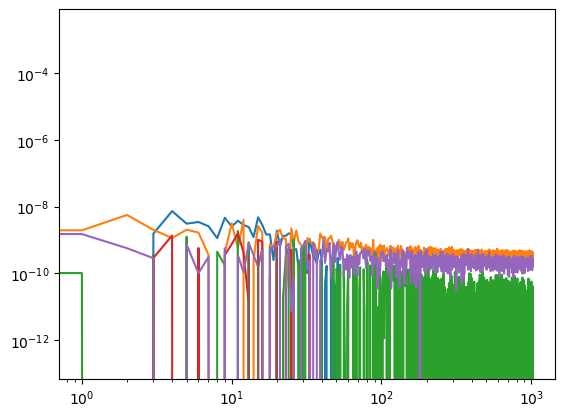

In [42]:
import matplotlib.pyplot as plt
plt.loglog(cross_12_bnt)
plt.loglog(cross_13_bnt)
plt.loglog(cross_14_bnt)
plt.loglog(cross_23_bnt)
plt.loglog(cross_24_bnt)
plt.loglog(cross_34_bnt)

# plt.ylim(1e-11, 1e-7)

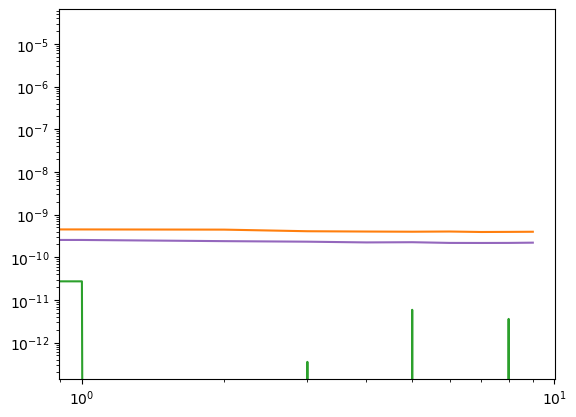

In [44]:
plt.loglog(rebinned_cross_12_bnt)
plt.loglog(rebinned_cross_13_bnt)
plt.loglog(rebinned_cross_14_bnt)
plt.loglog(rebinned_cross_23_bnt)
plt.loglog(rebinned_cross_24_bnt)
plt.loglog(rebinned_cross_34_bnt)

### aggregated

In [14]:
aggregated_data_bnt = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/all_bnt_cross_cls_fiducial_nobaryons_bins1234_noisy_s0.26.npy")
aggregated_data_bnt_bar = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/all_bnt_cross_cls_fiducial_baryonified_bins1234_noisy_s0.26.npy")

In [15]:
aggregated_data_bnt.shape, aggregated_data_bnt_bar.shape

((200, 6150), (200, 6150))

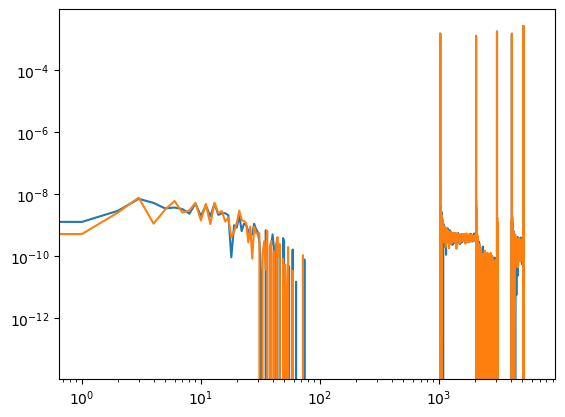

In [17]:
import matplotlib.pyplot as plt
plt.loglog(aggregated_data_bnt[10])
plt.loglog(aggregated_data_bnt_bar[10])

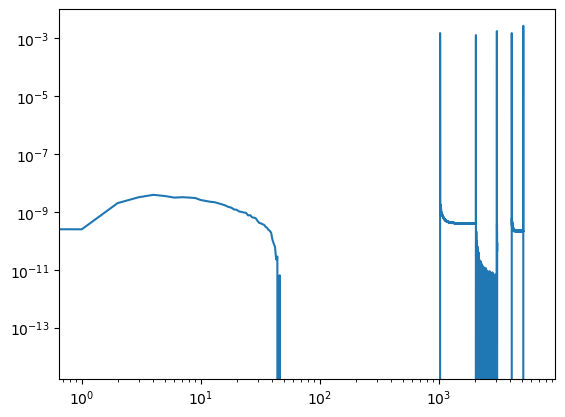

In [12]:
plt.loglog(aggregated_data_bnt.mean(axis=0))

(1e-10, 1e-07)

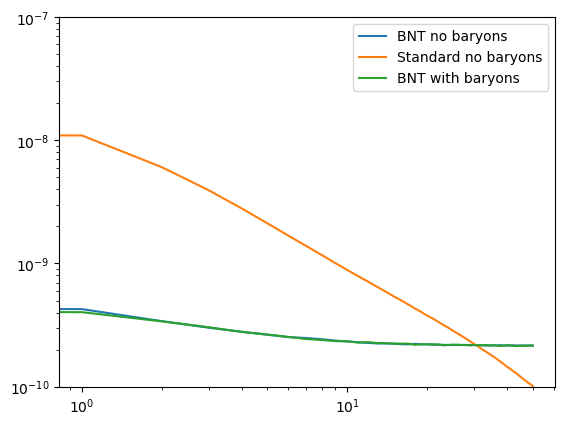

In [25]:
# rebin the mean spectrum by a factor of 10
mean_spectrum_bnt = aggregated_data_bnt.mean(axis=0)
rebin_factor = 20
rebinned_spectrum_bnt = mean_spectrum_bnt[:len(mean_spectrum_bnt) - len(mean_spectrum_bnt) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)
rebinned_spectrum = mean_spectrum[:len(mean_spectrum) - len(mean_spectrum) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)

mean_spectrum_bnt_bar = aggregated_data_bnt_bar.mean(axis=0)
rebin_factor = 20
rebinned_spectrum_bnt_bar = mean_spectrum_bnt_bar[:len(mean_spectrum_bnt_bar) - len(mean_spectrum_bnt_bar) % rebin_factor].reshape(-1, rebin_factor).mean(axis=1)   

bin_i = 4
bin_f = 5
plt.loglog(rebinned_spectrum_bnt[bin_i*1025//rebin_factor:bin_f*1025//rebin_factor], label='BNT no baryons')
plt.loglog(rebinned_spectrum[bin_i*1025//rebin_factor:bin_f*1025//rebin_factor], label='Standard no baryons')
plt.loglog(rebinned_spectrum_bnt_bar[bin_i*1025//rebin_factor:bin_f*1025//rebin_factor], label='BNT with baryons')
plt.legend()
plt.ylim(1e-10, 1e-7)

## Grid

In [20]:
data_grid = np.load("/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_bnt_cross_cls_grid_nobaryons_bins1234_noisy_s0.26.npy")

In [21]:
# rebin the data
rebin_factor = 100
rebinned_data_grid = data_grid[:, :data_grid.shape[1] - data_grid.shape[1] % rebin_factor].reshape(data_grid.shape[0], -1, rebin_factor).mean(axis=2)
rebinned_data_grid.shape

(16965, 61)

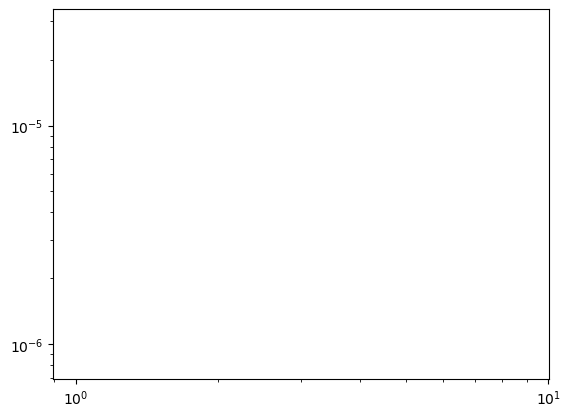

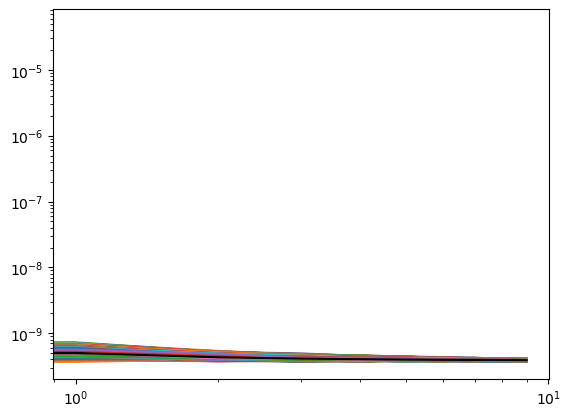

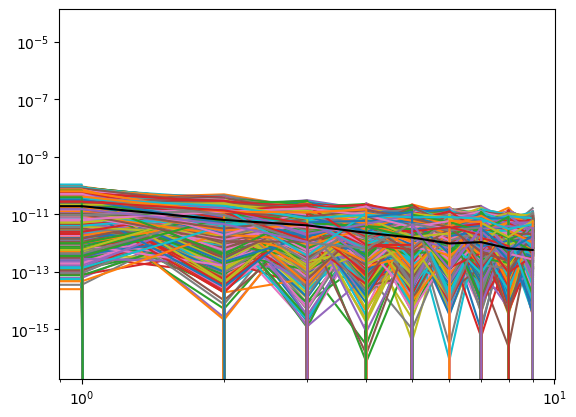

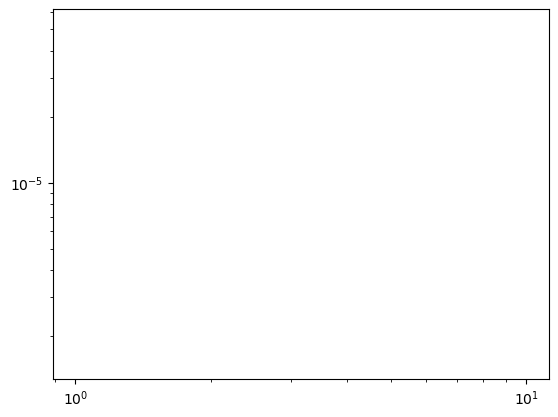

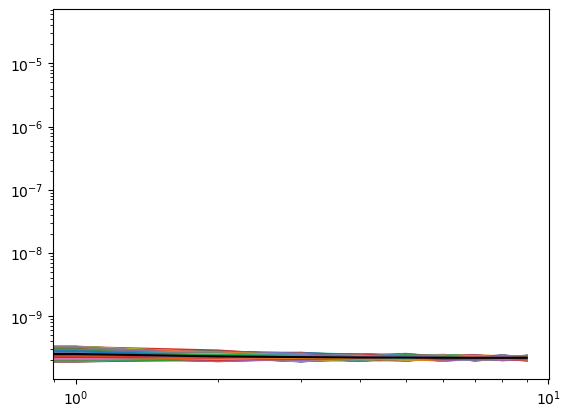

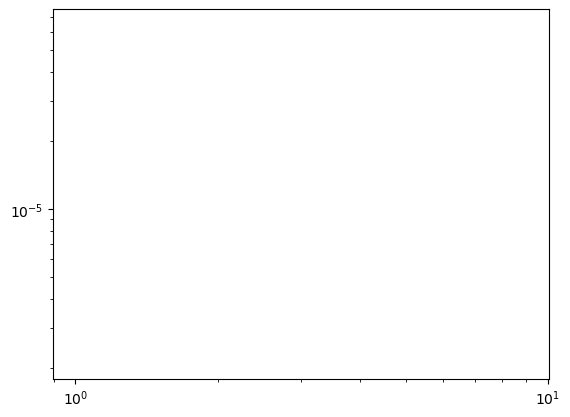

In [27]:
for j in range(6):
    for i in range(16965):
        plt.loglog(rebinned_data_grid[i][j*1025//rebin_factor:(j+1)*1025//rebin_factor])
    plt.loglog(rebinned_spectrum[j*1025//rebin_factor:(j+1)*1025//rebin_factor], color='black')
    plt.show()